In [1]:
from utils import read_fit, read_xrr

In [2]:
graded_model = read_fit("graded/graded_fit.pkl", material="znpc")

(<Axes: ylabel='Reflectivity'>,
 <Axes: xlabel='$q (\\AA^{-1})$', ylabel='Anisotropy'>)

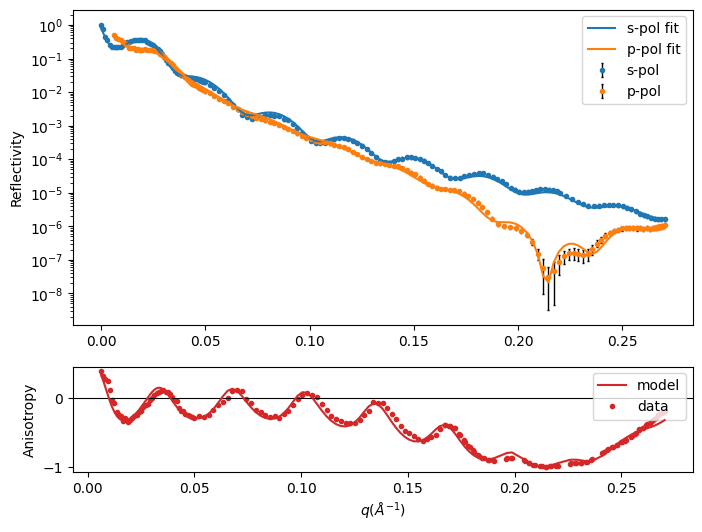

In [3]:
graded_model.plot()

In [4]:
from utils.models import (
    AnisotropyObjective,
    CurveFitter,
    ReflectModel,
    Transform,
    configure_refloxide_fitting,
)
from utils.refloxide_profile import model_bookended_refloxide

configure_refloxide_fitting(use_rust=True, parallel=False)

In [9]:
mat = graded_model.model.structure[1]

mat.tau_vac.setp(bounds=(0, 30))

In [10]:
import matplotlib.pyplot as plt

fitter = CurveFitter(graded_model)
fitter.fit("differential_evolution", workers=8, x0 = [v.value for v in graded_model.varying_parameters()])
fitter.objective.plot()
plt.show()
fitter.objective.model.structure.plot()
plt.show()

0it [00:00, ?it/s]/Users/hduva/projects/refl-analysis/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:518: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
0it [00:04, ?it/s]


AttributeError: 'BookendedOrientationProfile' object has no attribute '_mesh_cache_thick'

In [14]:
print(fitter.objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.46145 +/- 0.023, bounds=[0.5, 2.1]>
<Parameter:   'scale_p'   , value=1.47366 +/- 0.0127, bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s', value=0.307712 +/- 0.019, bounds=[-1.5, 1.5]>
<Parameter:'theta_offset_p', value=0.214836 +/- 0.0432, bounds=[-1.5, 1.5]>
<Parameter: 'total_thick' , value=189.672 +/- 0.243, bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=7.46683 +/- 0.169, bounds=[0.0, 10.0]>
<Parameter:   'tau_si'    , value=22.1784 +/- 0.684, bounds=[0.5, 25.0]>
<Parameter:   'tau_vac'   , value=25 +/- 1.75 , bounds=[0.5, 25.0]>
<Parameter: 'alpha_bulk'  , value=1.28228 +/- 0.00834, bounds=[0.0, 1.5707963267948966]>
<Parameter:  'alpha_si'   , value=0.601411 +/- 0.00695, bounds=[0.0, 0.7853981633974483]>
<Parameter:  'alpha_vac'  , value=1.00985 +/- 0.00781, bounds=[0.0, 1.5707963267948966]>


In [33]:
objective = fitter.objective
objective.model.structure.components[1].density_bulk.setp(vary=False, bounds=(1, 2.5))
objective.model.structure.components[1].density_si.constraint = None
objective.model.structure.components[1].density_si.setp(vary=True, bounds=(0.5, 2.5))
objective.model.structure.components[1].density_vac.constraint = None
objective.model.structure.components[1].density_vac.setp(vary=True, bounds=(0.5, 2.5))

print(objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.46169 +/- 0.023, bounds=[0.5, 2.1]>
<Parameter:   'scale_p'   , value=1.47371 +/- 0.0127, bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s', value=0.308006 +/- 0.019, bounds=[-1.5, 1.5]>
<Parameter:'theta_offset_p', value=0.215065 +/- 0.0432, bounds=[-1.5, 1.5]>
<Parameter: 'total_thick' , value=189.668 +/- 0.243, bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=7.46677 +/- 0.169, bounds=[0.0, 10.0]>
<Parameter: 'density_si'  , value=1.63852          , bounds=[0.5, 2.5]>
<Parameter: 'density_vac' , value=1.63852          , bounds=[0.5, 2.5]>
<Parameter:   'tau_si'    , value=22.1621 +/- 0.683, bounds=[0.5, 25.0]>
<Parameter:   'tau_vac'   , value=24 +/- 1.75 , bounds=[0.0, 25.0]>
<Parameter: 'alpha_bulk'  , value=1.2822 +/- 0.00833, bounds=[0.0, 1.5707963267948966]>
<Parameter:  'alpha_si'   , value=0.601355 +/- 0.00696, bounds=[0.0, 

0it [00:00, ?it/s]/Users/hduva/projects/refl-analysis/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:518: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
-0.5855137813256654: : 75it [02:27,  1.96s/it]


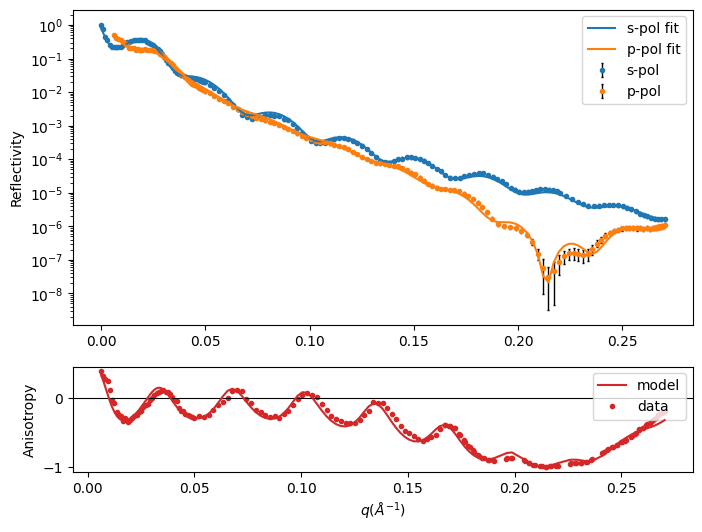

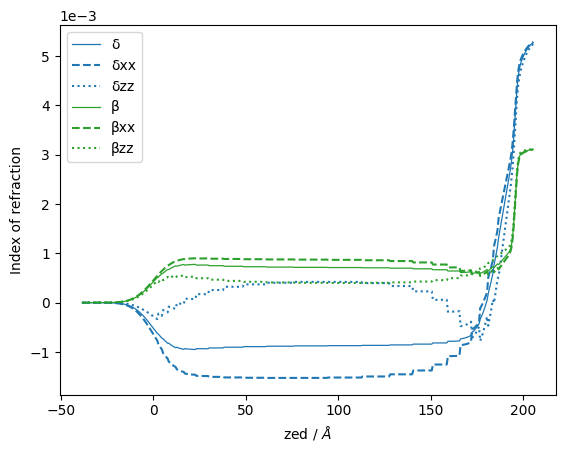

In [34]:
fitter = CurveFitter(objective)

fitter.fit(
    "differential_evolution",
    workers=8,
    x0=[v.value for v in objective.varying_parameters()],
)
fitter.objective.plot()
plt.show()
fitter.objective.model.structure.plot()
plt.show()

In [36]:
import pickle

from utils import models_root

with open(
    models_root / "xrr" / "znpc" / "graded" / "graded_fit.pkl",
    "wb",
) as f:
    pickle.dump(fitter.objective, f)